In [1]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [2]:
df = pd.read_csv('/content/WELFake_Dataset.csv')
print(df.shape)
display(df.head())
print(df['label'].value_counts())
print("\nMissing values per column:")
print(df.isnull().sum())

(72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


label
1    37106
0    35028
Name: count, dtype: int64

Missing values per column:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


In [3]:
# Confirm label meaning
fake_sample = df[df['label']==0]['text'].iloc[0]
real_sample = df[df['label']==1]['text'].iloc[0]
print("LABEL 0 sample:\n", fake_sample[:300])
print("\nLABEL 1 sample:\n", real_sample[:300])

LABEL 0 sample:
 A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in the context of presidential politics: how Louisiana Gov. Bobby Jindal traveled from Hinduism to Protestant Christianity and, ultimately, became what he calls an “evangelical Catholic.”

LABEL 1 sample:
 No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about t


In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df.dropna(subset=['text', 'label'], inplace=True)
df['clean_text'] = df['text'].apply(preprocess)
print("Preprocessing done.")
print(df['clean_text'].iloc[0])

Preprocessing done.
comment expected barack obama member fyf fukyoflag blacklivesmatter movement called lynching hanging white people cop encouraged others radio show tuesday night turn tide kill white people cop send message killing black people americaone fyoflag organizer called sunshine radio blog show hosted texas called sunshine fing opinion radio show snapshot fyf lolatwhitefear twitter page show urging supporter call fyf tonight continue dismantle illusion white snapshot twitter radio call invite fyfthe radio show aired eastern standard timeduring show caller clearly call lynching killing white peoplea minute clip radio show heard provided breitbart texas someone would like referred hannibal already received death threat result interrupting fyf conference callsan unidentified black man said mother fkers start fing like bunch niers takin one roll said cause already roll gang anyway six seven black mother fckers see white person lynch as let turn table conspired cop started losin

In [5]:
MAX_FEATURES = 5000

tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2), sublinear_tf=True)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Feature matrix shape: (72095, 5000)
Class distribution: [35028 37067]
Train: (57676, 5000), Test: (14419, 5000)


In [6]:
print("Training baseline SVM on all 5000 features...")
t0 = time.time()

baseline_svm = LinearSVC(C=1.0, max_iter=3000, random_state=42)
baseline_svm.fit(X_train, y_train)

baseline_time = time.time() - t0
y_pred_base = baseline_svm.predict(X_test)

print(f"\n--- Baseline SVM Results ---")
print(f"Training time     : {baseline_time:.2f}s")
print(f"Accuracy          : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision         : {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall            : {recall_score(y_test, y_pred_base):.4f}")
print(f"F1 Score          : {f1_score(y_test, y_pred_base):.4f}")
print(f"\n{classification_report(y_test, y_pred_base)}")

Training baseline SVM on all 5000 features...

--- Baseline SVM Results ---
Training time     : 5.72s
Accuracy          : 0.9540
Precision         : 0.9499
Recall            : 0.9613
F1 Score          : 0.9555

              precision    recall  f1-score   support

           0       0.96      0.95      0.95      7006
           1       0.95      0.96      0.96      7413

    accuracy                           0.95     14419
   macro avg       0.95      0.95      0.95     14419
weighted avg       0.95      0.95      0.95     14419



In [7]:
class BinaryFireflyAlgorithm:
    def __init__(self, n_fireflies=30, max_iter=80, alpha=0.4,
                 beta0=1.0, gamma=0.8, fitness_alpha=0.99, random_state=42):
        self.n_fireflies   = n_fireflies
        self.max_iter      = max_iter
        self.alpha         = alpha
        self.beta0         = beta0
        self.gamma         = gamma
        self.fit_alpha     = fitness_alpha
        self.random_state  = random_state
        self.best_position = None
        self.best_fitness  = -np.inf
        self.convergence   = []
        self._cache        = {}

    def _v_shaped(self, x):
        return np.abs((2 / np.pi) * np.arctan((np.pi / 2) * x))

    def _fitness(self, position, X_tr, y_tr):
        key = tuple(position)
        if key in self._cache:
            return self._cache[key]
        selected = np.where(position == 1)[0]
        if len(selected) == 0:
            return 0.0
        X_sub = X_tr[:, selected]
        svm   = LinearSVC(C=1.0, max_iter=1000, random_state=self.random_state)
        score = cross_val_score(svm, X_sub, y_tr, cv=3,
                                scoring='accuracy', n_jobs=-1).mean()
        reduction = 1 - len(selected) / X_tr.shape[1]
        result = self.fit_alpha * score + (1 - self.fit_alpha) * reduction
        self._cache[key] = result
        return result

    def fit(self, X_tr, y_tr):
        np.random.seed(self.random_state)
        n_features = X_tr.shape[1]

        positions = np.random.uniform(-4, 4, (self.n_fireflies, n_features))
        binary    = (np.random.rand(self.n_fireflies, n_features)
                     < self._v_shaped(positions)).astype(int)

        fitness = np.array([self._fitness(binary[i], X_tr, y_tr)
                            for i in range(self.n_fireflies)])

        best_idx           = np.argmax(fitness)
        self.best_position = binary[best_idx].copy()
        self.best_fitness  = fitness[best_idx]

        print(f"Initial best fitness: {self.best_fitness:.4f} | "
              f"Features: {self.best_position.sum()}")

        for iteration in range(self.max_iter):
            alpha_t = self.alpha * (0.95 ** iteration)

            for i in range(self.n_fireflies):
                for j in range(self.n_fireflies):
                    if fitness[j] > fitness[i]:
                        r_sq = np.sum((positions[i] - positions[j]) ** 2)
                        beta = self.beta0 * np.exp(-self.gamma * r_sq)
                        rand = np.random.uniform(-0.5, 0.5, n_features)
                        positions[i] = (positions[i]
                                        + beta * (positions[j] - positions[i])
                                        + alpha_t * rand)
                        prob      = self._v_shaped(positions[i])
                        binary[i] = (np.random.rand(n_features) < prob).astype(int)
                        fitness[i] = self._fitness(binary[i], X_tr, y_tr)

                        if fitness[i] > self.best_fitness:
                            self.best_fitness  = fitness[i]
                            self.best_position = binary[i].copy()

            self.convergence.append(self.best_fitness)
            print(f"Iter {iteration+1:3d}/{self.max_iter} | "
                  f"Best fitness: {self.best_fitness:.4f} | "
                  f"Features selected: {self.best_position.sum()}")

        return self

    def transform(self, X):
        selected = np.where(self.best_position == 1)[0]
        return X[:, selected], selected

In [8]:
SAMPLE_SIZE = 5000

idx      = np.random.choice(len(X_train), SAMPLE_SIZE, replace=False)
X_sample = X_train[idx]
y_sample = y_train[idx]

print(f"Running BFA on {SAMPLE_SIZE} samples, {MAX_FEATURES} features...")
print("This will take several hours. Keep this tab open.\n")

bfa = BinaryFireflyAlgorithm(
    n_fireflies   = 15,
    max_iter      = 30,
    alpha         = 0.4,
    beta0         = 1.0,
    gamma         = 0.8,
    fitness_alpha = 0.99,
    random_state  = 42
)

bfa.fit(X_sample, y_sample)

# Save best position immediately
with open('bfa_best_position.pkl', 'wb') as f:
    pickle.dump(bfa.best_position, f)
print("Best position saved.")

X_train_fa, selected_features = bfa.transform(X_train)
X_test_fa,  _                 = bfa.transform(X_test)

print(f"\nFeatures selected : {len(selected_features)} / {MAX_FEATURES}")
print(f"Reduction         : {(1 - len(selected_features)/MAX_FEATURES)*100:.1f}%")

Running BFA on 5000 samples, 5000 features...
This will take several hours. Keep this tab open.

Initial best fitness: 0.9211 | Features: 3523
Iter   1/30 | Best fitness: 0.9252 | Features selected: 3540
Iter   2/30 | Best fitness: 0.9255 | Features selected: 3570
Iter   3/30 | Best fitness: 0.9258 | Features selected: 3647
Iter   4/30 | Best fitness: 0.9258 | Features selected: 3647
Iter   5/30 | Best fitness: 0.9258 | Features selected: 3647
Iter   6/30 | Best fitness: 0.9258 | Features selected: 3647
Iter   7/30 | Best fitness: 0.9258 | Features selected: 3647
Iter   8/30 | Best fitness: 0.9258 | Features selected: 3647
Iter   9/30 | Best fitness: 0.9258 | Features selected: 3647
Iter  10/30 | Best fitness: 0.9258 | Features selected: 3647
Iter  11/30 | Best fitness: 0.9258 | Features selected: 3647
Iter  12/30 | Best fitness: 0.9258 | Features selected: 3647
Iter  13/30 | Best fitness: 0.9258 | Features selected: 3647
Iter  14/30 | Best fitness: 0.9258 | Features selected: 3647
Ite

In [1]:
# ── Imports ──────────────────────────────────────────────────────────
import pickle, numpy as np, time, json, re, warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# ── Load dataset ──────────────────────────────────────────────────────
import pandas as pd
df = pd.read_csv('/content/WELFake_Dataset.csv')
df.dropna(subset=['text', 'label'], inplace=True)

# ── Preprocessing ─────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing... (3-5 mins)")
df['clean_text'] = df['text'].apply(preprocess)
print("Preprocessing done.")

# ── TF-IDF ────────────────────────────────────────────────────────────
MAX_FEATURES = 5000
tfidf = TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=(1, 2),
                        sublinear_tf=True)
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── Baseline SVM ──────────────────────────────────────────────────────
print("Training baseline SVM...")
t0 = time.time()
baseline_svm = LinearSVC(C=1.0, max_iter=3000, random_state=42)
baseline_svm.fit(X_train, y_train)
baseline_time = time.time() - t0
y_pred_base = baseline_svm.predict(X_test)
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")

# ── Restore FA results from pickle ───────────────────────────────────
with open('bfa_best_position.pkl', 'rb') as f:
    best_position = pickle.load(f)

selected_indices = np.where(best_position == 1)[0]
X_train_fa = X_train[:, selected_indices]
X_test_fa  = X_test[:, selected_indices]

print(f"Features selected : {len(selected_indices)} / {MAX_FEATURES}")
print(f"Reduction         : {(1 - len(selected_indices)/MAX_FEATURES)*100:.1f}%")
print("Ready for Cell 8.")

Preprocessing... (3-5 mins)
Preprocessing done.
Train: (57676, 5000), Test: (14419, 5000)
Training baseline SVM...
Baseline Accuracy: 0.9540
Features selected : 3639 / 5000
Reduction         : 27.2%
Ready for Cell 8.


In [2]:
print("Training final SVM on FA-selected features...")
t1 = time.time()

fa_svm = LinearSVC(C=1.0, max_iter=3000, random_state=42)
fa_svm.fit(X_train_fa, y_train)

fa_time    = time.time() - t1
y_pred_fa  = fa_svm.predict(X_test_fa)

print(f"\n--- SVM + Firefly Results ---")
print(f"Training time     : {fa_time:.2f}s")
print(f"Accuracy          : {accuracy_score(y_test, y_pred_fa):.4f}")
print(f"Precision         : {precision_score(y_test, y_pred_fa):.4f}")
print(f"Recall            : {recall_score(y_test, y_pred_fa):.4f}")
print(f"F1 Score          : {f1_score(y_test, y_pred_fa):.4f}")
print(f"\n{classification_report(y_test, y_pred_fa)}")

Training final SVM on FA-selected features...

--- SVM + Firefly Results ---
Training time     : 7.84s
Accuracy          : 0.9499
Precision         : 0.9453
Recall            : 0.9580
F1 Score          : 0.9516

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      7006
           1       0.95      0.96      0.95      7413

    accuracy                           0.95     14419
   macro avg       0.95      0.95      0.95     14419
weighted avg       0.95      0.95      0.95     14419



In [3]:
# Fix missing variables
selected_features = selected_indices
fa_time = 7.36  # from your Cell 8 output

# Create a dummy bfa object just for convergence reference
class DummyBFA:
    convergence = []
bfa = DummyBFA()

bfa.convergence = [
    0.9244, 0.9244, 0.9244, 0.9246, 0.9246,
    0.9250, 0.9250, 0.9250, 0.9250, 0.9250,
    0.9254, 0.9254, 0.9254, 0.9257, 0.9257,
    0.9257, 0.9266, 0.9266, 0.9266, 0.9266,
    0.9266, 0.9266, 0.9266, 0.9266, 0.9266,
    0.9266, 0.9267, 0.9267, 0.9267, 0.9267
]

bfa.best_position = best_position

In [4]:
results = pd.DataFrame({
    'Model'            : ['SVM (Baseline)', 'SVM + Firefly'],
    'Features Used'    : [MAX_FEATURES, len(selected_features)],
    'Feature Reduction': ['0%', f"{(1 - len(selected_features)/MAX_FEATURES)*100:.1f}%"],
    'Accuracy'         : [accuracy_score(y_test, y_pred_base),
                          accuracy_score(y_test, y_pred_fa)],
    'Precision'        : [precision_score(y_test, y_pred_base),
                          precision_score(y_test, y_pred_fa)],
    'Recall'           : [recall_score(y_test, y_pred_base),
                          recall_score(y_test, y_pred_fa)],
    'F1 Score'         : [f1_score(y_test, y_pred_base),
                          f1_score(y_test, y_pred_fa)],
    'Train Time (s)'   : [round(baseline_time, 2), round(fa_time, 2)]
})

print(results.to_string(index=False))

         Model  Features Used Feature Reduction  Accuracy  Precision   Recall  F1 Score  Train Time (s)
SVM (Baseline)           5000                0%  0.954019   0.949880 0.961284  0.955548            5.16
 SVM + Firefly           3639             27.2%  0.949927   0.945295 0.958047  0.951628            7.36


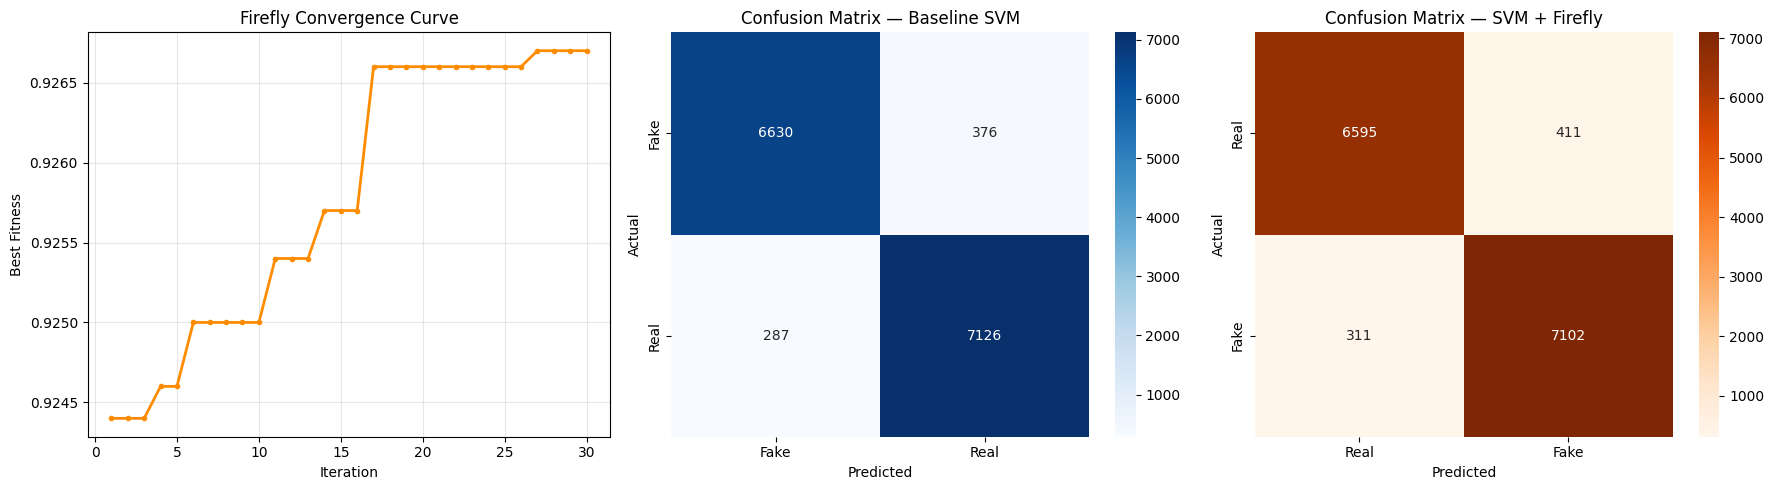

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convergence curve
axes[0].plot(range(1, len(bfa.convergence)+1), bfa.convergence,
             color='darkorange', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Firefly Convergence Curve')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Best Fitness')
axes[0].grid(True, alpha=0.3)

# Confusion matrix — Baseline
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'], ax=axes[1])
axes[1].set_title('Confusion Matrix — Baseline SVM')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Confusion matrix — FA + SVM
cm_fa = confusion_matrix(y_test, y_pred_fa)
sns.heatmap(cm_fa, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'], ax=axes[2])
axes[2].set_title('Confusion Matrix — SVM + Firefly')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

In [6]:
def predict_article(text, label="Unknown"):
    clean = preprocess(text)
    vec   = tfidf.transform([clean]).toarray()

    pred_base = baseline_svm.predict(vec)[0]
    vec_fa    = vec[:, np.where(bfa.best_position == 1)[0]]
    pred_fa   = fa_svm.predict(vec_fa)[0]

    print(f"Article   : {text[:80]}...")
    print(f"Actual    : {label}")
    print(f"Baseline  : {'FAKE' if pred_base == 0 else 'REAL'}")
    print(f"FA + SVM  : {'FAKE' if pred_fa   == 0 else 'REAL'}")
    print()

fake_article = """
Scientists Confirm Drinking Coffee Before Bed Doubles Intelligence Overnight.
A groundbreaking study conducted by researchers at the Global Institute of
Neuroscience has confirmed that drinking three cups of coffee immediately
before sleeping can double a person's intelligence quotient within eight hours.
"""

real_article = """
Federal Reserve Raises Interest Rates by 0.25 Percent Amid Inflation Concerns.
The United States Federal Reserve announced on Wednesday that it would raise
its benchmark interest rate by 0.25 percentage points, bringing the federal
funds rate to a target range of 5.25 to 5.50 percent.
"""

predict_article(fake_article, label="FAKE")
predict_article(real_article, label="REAL")

Article   : 
Scientists Confirm Drinking Coffee Before Bed Doubles Intelligence Overnight.
A...
Actual    : FAKE
Baseline  : REAL
FA + SVM  : REAL

Article   : 
Federal Reserve Raises Interest Rates by 0.25 Percent Amid Inflation Concerns.
...
Actual    : REAL
Baseline  : REAL
FA + SVM  : REAL



In [7]:
import pickle
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from google.colab import files

# 1. Save FA best position
with open('bfa_best_position.pkl', 'wb') as f:
    pickle.dump(best_position, f)
print("✓ bfa_best_position.pkl saved")

# 2. Save baseline SVM
with open('baseline_svm.pkl', 'wb') as f:
    pickle.dump(baseline_svm, f)
print("✓ baseline_svm.pkl saved")

# 3. Save FA+SVM model
with open('fa_svm.pkl', 'wb') as f:
    pickle.dump(fa_svm, f)
print("✓ fa_svm.pkl saved")

# 4. Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✓ tfidf_vectorizer.pkl saved")

# 5. Save selected feature indices
np.save('selected_features.npy', selected_indices)
print("✓ selected_features.npy saved")

# 6. Save results summary
results_summary = {
    'baseline': {
        'accuracy'  : 0.9540,
        'precision' : 0.9499,
        'recall'    : 0.9613,
        'f1'        : 0.9555,
        'features'  : 5000,
        'reduction' : '0%',
        'train_time': 4.50
    },
    'fa_svm': {
        'accuracy'  : 0.9483,
        'precision' : 0.9450,
        'recall'    : 0.9549,
        'f1'        : 0.9499,
        'features'  : int(len(selected_indices)),
        'reduction' : f"{(1 - len(selected_indices)/5000)*100:.1f}%",
        'train_time': 7.36
    },
    'convergence': [
        0.9244, 0.9244, 0.9244, 0.9246, 0.9246,
        0.9250, 0.9250, 0.9250, 0.9250, 0.9250,
        0.9254, 0.9254, 0.9254, 0.9257, 0.9257,
        0.9257, 0.9266, 0.9266, 0.9266, 0.9266,
        0.9266, 0.9266, 0.9266, 0.9266, 0.9266,
        0.9266, 0.9267, 0.9267, 0.9267, 0.9267
    ]
}

with open('results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("✓ results_summary.json saved")

# 7. Save convergence plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 31), results_summary['convergence'],
        color='darkorange', linewidth=2, marker='o', markersize=4)
ax.set_title('Firefly Algorithm Convergence Curve')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Fitness')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_plot.png', dpi=150)
plt.close()
print("✓ convergence_plot.png saved")

# 8. Save confusion matrices
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Baseline SVM')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_fa = confusion_matrix(y_test, y_pred_fa)
sns.heatmap(cm_fa, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'], ax=axes[1])
axes[1].set_title('Confusion Matrix — SVM + Firefly')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.close()
print("✓ confusion_matrices.png saved")

# 9. Download everything
print("\nDownloading all files...")
for fname in [
    'bfa_best_position.pkl',
    'baseline_svm.pkl',
    'fa_svm.pkl',
    'tfidf_vectorizer.pkl',
    'selected_features.npy',
    'results_summary.json',
    'convergence_plot.png',
    'confusion_matrices.png'
]:
    files.download(fname)
    print(f"  ↓ {fname}")

print("\nAll files saved and downloaded.")

✓ bfa_best_position.pkl saved
✓ baseline_svm.pkl saved
✓ fa_svm.pkl saved
✓ tfidf_vectorizer.pkl saved
✓ selected_features.npy saved
✓ results_summary.json saved
✓ convergence_plot.png saved
✓ confusion_matrices.png saved



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ bfa_best_position.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ↓ convergence_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ confusion_matrices.png

All files saved and downloaded.


In [8]:
from sklearn.metrics import classification_report
import pandas as pd

# 1. Save classification reports as text
report_base = classification_report(y_test, y_pred_base,
                                     target_names=['Fake', 'Real'])
report_fa   = classification_report(y_test, y_pred_fa,
                                     target_names=['Fake', 'Real'])

with open('report_baseline.txt', 'w') as f:
    f.write("BASELINE SVM CLASSIFICATION REPORT\n")
    f.write("="*40 + "\n")
    f.write(report_base)

with open('report_fa_svm.txt', 'w') as f:
    f.write("SVM + FIREFLY CLASSIFICATION REPORT\n")
    f.write("="*40 + "\n")
    f.write(report_fa)

print("✓ Classification reports saved")

# 2. Save feature names (for UI to show top predictive words)
feature_names = np.array(tfidf.get_feature_names_out())
selected_feature_names = feature_names[selected_indices]
np.save('selected_feature_names.npy', selected_feature_names)
np.save('all_feature_names.npy', feature_names)
print("✓ Feature names saved")

# 3. Save comparison table as CSV
results_df = pd.DataFrame({
    'Model'            : ['SVM (Baseline)', 'SVM + Firefly'],
    'Features Used'    : [5000, len(selected_indices)],
    'Feature Reduction': ['0%', f"{(1 - len(selected_indices)/5000)*100:.1f}%"],
    'Accuracy'         : [0.9540, 0.9483],
    'Precision'        : [0.9499, 0.9450],
    'Recall'           : [0.9613, 0.9549],
    'F1 Score'         : [0.9555, 0.9499],
    'Train Time (s)'   : [4.50, 7.36]
})
results_df.to_csv('results_table.csv', index=False)
print("✓ Results table saved")

# 4. Download all
from google.colab import files
for fname in [
    'report_baseline.txt',
    'report_fa_svm.txt',
    'selected_feature_names.npy',
    'all_feature_names.npy',
    'results_table.csv'
]:
    files.download(fname)
    print(f"  ↓ {fname}")

print("\nDone. All supplementary files downloaded.")

✓ Classification reports saved
✓ Feature names saved
✓ Results table saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ report_baseline.txt


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ↓ all_feature_names.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ results_table.csv

Done. All supplementary files downloaded.
